In [42]:
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/climate_watch")

df_test = pd.read_sql("SELECT * FROM GlobalLandTemperaturesByCity LIMIT 5", engine)
df_test


tables = [
    "GlobalLandTemperaturesByCity",
    "GlobalLandTemperaturesByCountry",
    "GlobalLandTemperaturesByMajorCity",
    "GlobalLandTemperaturesByState",
    "globaltemperatures"
]

with engine.connect() as conn:
    for table in tables:
        subset_table = f"{table}_subset"
        
        conn.execute(text(f"DROP TABLE IF EXISTS {subset_table}"))
        conn.execute(text(f"""
            CREATE TABLE {subset_table} AS
            SELECT *
            FROM {table}
            WHERE YEAR(dt) >= 1980;
        """))
        
        print(f"Klaar: {subset_table}")

conn.commit()

Klaar: GlobalLandTemperaturesByCity_subset
Klaar: GlobalLandTemperaturesByCountry_subset
Klaar: GlobalLandTemperaturesByMajorCity_subset
Klaar: GlobalLandTemperaturesByState_subset
Klaar: globaltemperatures_subset


In [144]:



# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCountry.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["Country"] = df["Country"].str.strip()

# 3. Fix specific known country-name issue if needed
#df["Country"] = df["Country"].replace({
 #   "Bonaire, Saint Eustatius And Saba": "Bonaire - Saint Eustatius and Saba"
#})

# 4. Check the result
#print(df[df["Country"].str.contains("Bonaire", na=False)])


# 3. Make subset
before_1980_temp = df[df["dt"].dt.year < 1980].copy()
df_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_subset.shape)
print(df_subset["Country"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_subset["AverageTemperature"] = (
    df_subset["AverageTemperature"]
    .fillna(df_subset.groupby("Country")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
country_avg = (
    df_subset
    .groupby("Country", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)

(577462, 4)
(98415, 4)
243


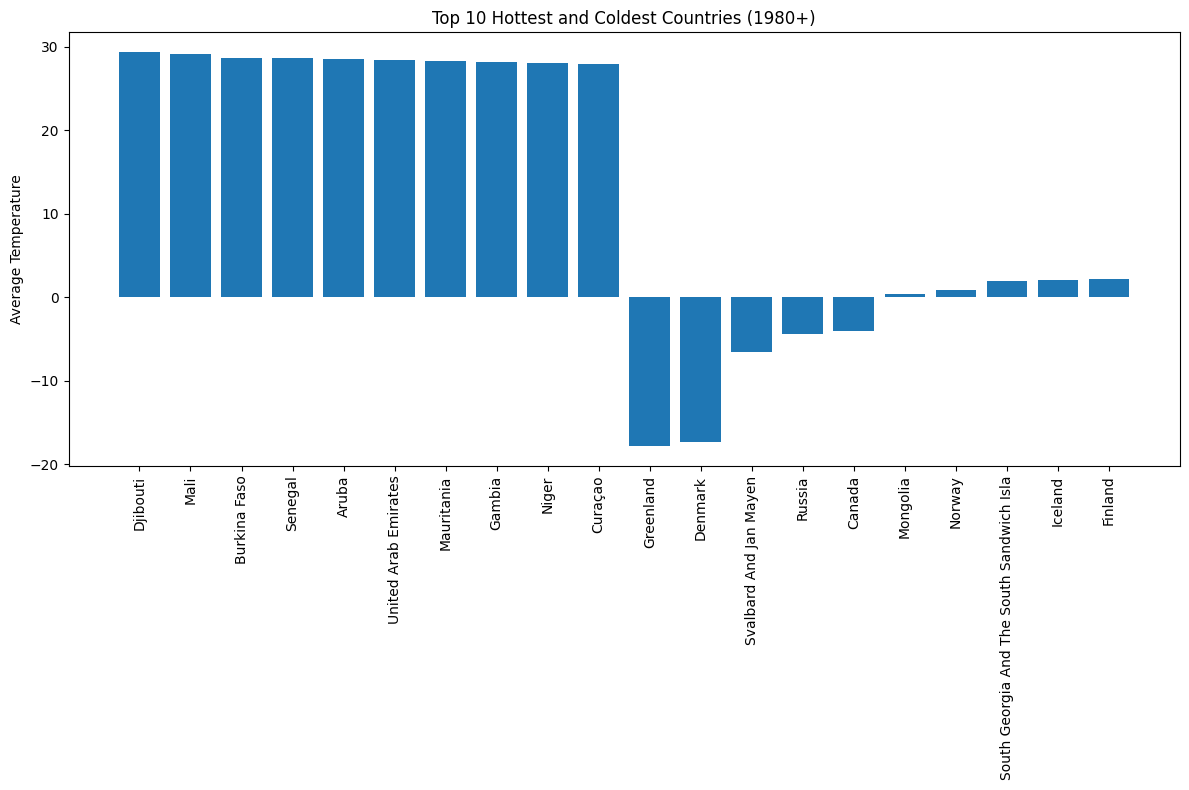

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot, top_cold])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["Country"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Countries (1980+)")
plt.tight_layout()
plt.show()

In [45]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_city_subset.shape)
print(df_city_subset["Country"].nunique())
print(df_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_city_subset["AverageTemperature"] = (
    df_city_subset["AverageTemperature"]
    .fillna(df_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_city_subset
    .groupby(["City", "Country", "Latitude", "Longitude"], as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_cold_city)

(8599212, 7)
(1421550, 7)
159
3448
Top 10 Hottest Cities:
            City   Country Latitude Longitude  AverageTemperature
1397      Jibuti  Djibouti   12.05N    42.74E           29.721559
3215  Umm Durman     Sudan   15.27N    32.50E           29.652307
1539    Khartoum     Sudan   15.27N    32.50E           29.652307
2140      Niamey     Niger   13.66N     2.48E           29.630797
1499     Kassala     Sudan   15.27N    35.83E           29.486295
2008       Mopti      Mali   15.27N     4.17W           29.425166
2527       Rabak     Sudan   13.66N    32.20E           29.135139
1655       Kusti     Sudan   13.66N    32.20E           29.135139
1829      Madras     India   13.66N    80.09E           29.041574
91      Ambattur     India   13.66N    80.09E           29.041574

Top 10 Coldest Cities:
                     City   Country Latitude Longitude  AverageTemperature
2168              Norilsk    Russia   69.92N    88.83E          -10.802074
1659                Kyzyl    Russia   52.2

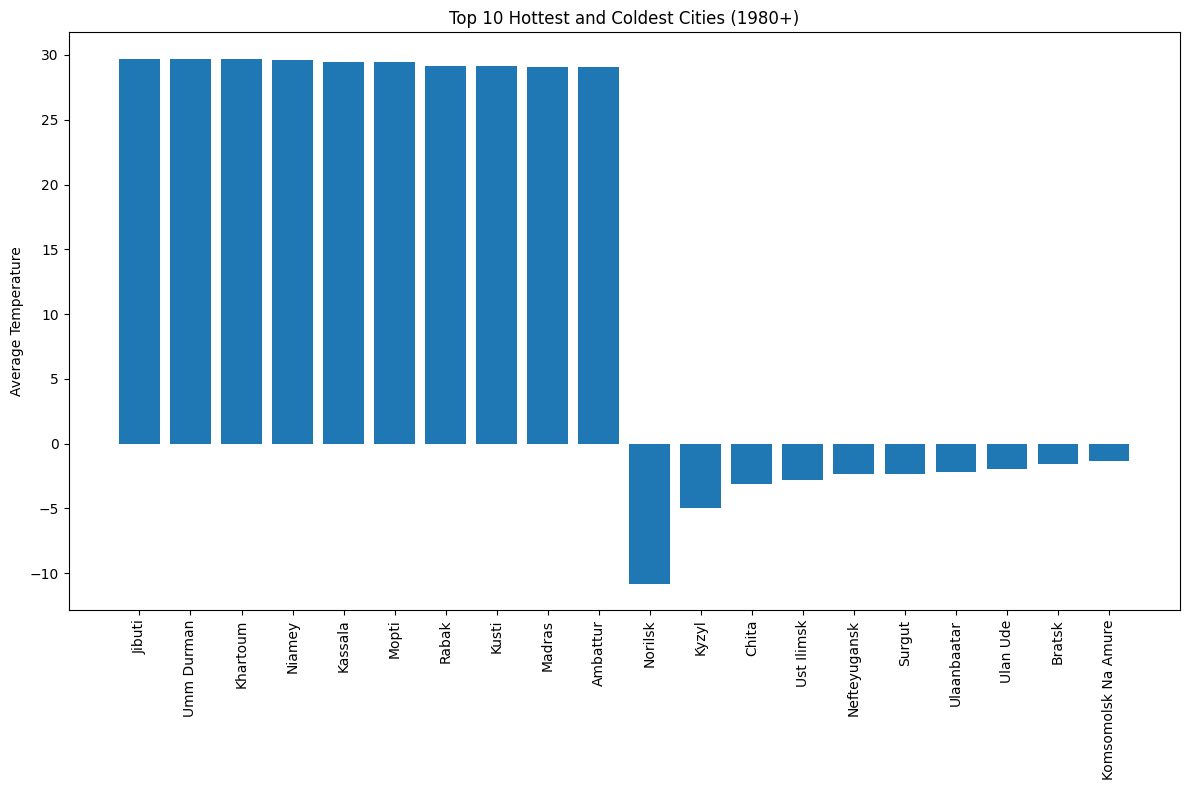

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot_city, top_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

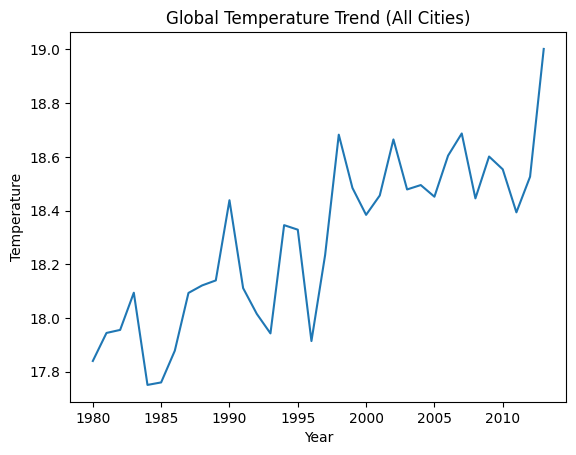

In [50]:
df_city_subset["year"] = df_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [51]:
city_yearly = (
    df_city_subset
    .groupby(["year", "City", "Country"], as_index=False)["AverageTemperature"]
    .mean()
)

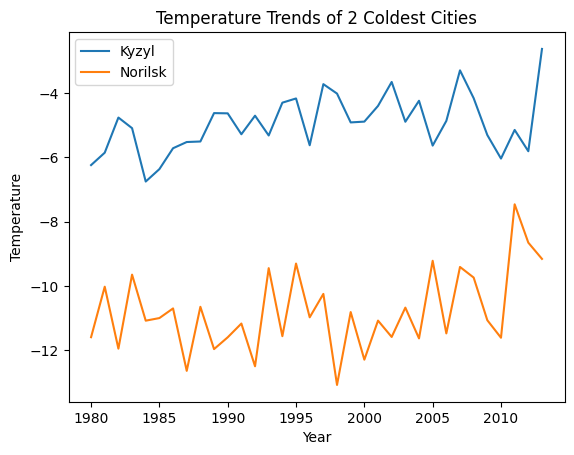

In [52]:
import matplotlib.pyplot as plt

# take only top 2
top_2_cold = top_cold_city.head(2)

subset = city_yearly[
    city_yearly["City"].isin(top_2_cold["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of 2 Coldest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()


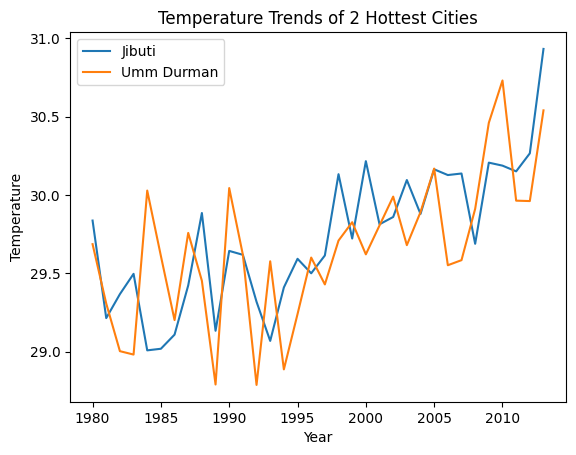

In [53]:
import matplotlib.pyplot as plt

# take only top 2
top_2_hot = top_hot_city.head(2)

subset = city_yearly[
    city_yearly["City"].isin(top_2_hot["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of 2 Hottest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

plt.show()

In [54]:
city_extremes = (
    df_city_subset.groupby("City")["AverageTemperature"]
    .agg(["min", "max"])
    .reset_index()
)

# verschil berekenen
city_extremes["range"] = city_extremes["max"] - city_extremes["min"]


top_variable = city_extremes.sort_values("range", ascending=False).head(10)
bottom_variable = city_extremes.sort_values("range", ascending=True).head(10)

print("Top 10 cities with the largest temperature range:")
print(top_variable[["City", "min", "max", "range"]])
print("\nBottom 10 cities with the smallest temperature range:")
print(bottom_variable[["City", "min", "max", "range"]])

Top 10 cities with the largest temperature range:
                 City     min     max   range
3361           Yichun -25.568  30.589  56.157
2122   Nizhnevartovsk -34.846  21.039  55.885
2134          Norilsk -38.447  16.382  54.829
2898           Surgut -33.730  20.729  54.459
2080     Nefteyugansk -33.730  20.729  54.459
3172       Ust Ilimsk -33.250  21.082  54.332
1635            Kyzyl -35.758  17.519  53.277
390   Blagoveshchensk -28.462  23.435  51.897
1150            Heihe -28.462  23.435  51.897
2745          Seversk -29.968  21.584  51.552

Bottom 10 cities with the smallest temperature range:
            City     min     max  range
1830      Manado  25.614  27.726  2.112
385       Bitung  25.614  27.726  2.112
3023     Ternate  25.938  28.070  2.132
1036   Gorontalo  25.750  28.018  2.268
2386   Pontianak  25.918  28.204  2.286
294     Baturaja  24.458  26.955  2.497
2413  Prabumulih  24.458  26.955  2.497
1919       Metro  25.254  27.752  2.498
2420   Pringsewu  25.254  27.

In [147]:
from scipy.stats import linregress

# year maken
df_city_subset["Year"] = df_city_subset["dt"].dt.year

# gemiddelde temperatuur per jaar per stad
yearly_temp = (
    df_city_subset.groupby(["City", "Year"])["AverageTemperature"]
    .mean()
    .reset_index()
)

slopes = []

# per stad trend berekenen
for city in yearly_temp["City"].unique():

    city_data = yearly_temp[yearly_temp["City"] == city]

    # genoeg data check
    if len(city_data) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            city_data["Year"],
            city_data["AverageTemperature"]
        )

        slopes.append({
            "City": city,
            "Slope": slope
        })

# dataframe maken
slope_df = pd.DataFrame(slopes)

# hoogste stijging
top_warming = slope_df.sort_values("Slope", ascending=False).head(10)

print(top_warming)

                City     Slope
2310       Pavlohrad  0.067550
2380         Poltava  0.066605
1604      Kremenchuk  0.066605
1185        Horlivka  0.066470
2754         Shakhty  0.066030
1818       Makiyivka  0.066030
2150   Novocherkassk  0.066030
2577  Rostov Na Donu  0.066030
291          Bataysk  0.066030
2937        Taganrog  0.066030


In [148]:
import numpy as np
import pandas as pd

# make sure dt is datetime
df_subset["dt"] = pd.to_datetime(df_subset["dt"])

# create year column
df_subset["Year"] = df_subset["dt"].dt.year

# average temperature per country per year
yearly_country_temp = (
    df_subset
    .groupby(["Country", "Year"])["AverageTemperature"]
    .mean()
    .reset_index()
)

country_slopes = []

for country in yearly_country_temp["Country"].unique():

    country_data = yearly_country_temp[
        yearly_country_temp["Country"] == country
    ].dropna(subset=["AverageTemperature"])

    # enough years of data
    if len(country_data) > 10:

        slope, intercept = np.polyfit(
            country_data["Year"],
            country_data["AverageTemperature"],
            1
        )

        country_slopes.append({
            "Country": country,
            "Slope_per_year": slope,
            "Slope_per_decade": slope * 10
        })

country_slope_df = pd.DataFrame(country_slopes)

top_warming_countries = (
    country_slope_df
    .sort_values("Slope_per_year", ascending=False)
    .head(10)
)

print(top_warming_countries)

                       Country  Slope_per_year  Slope_per_decade
209     Svalbard And Jan Mayen        0.082972          0.829723
87                   Greenland        0.082909          0.829094
57                     Denmark        0.081961          0.819609
228       United Arab Emirates        0.059918          0.599176
227                    Ukraine        0.059609          0.596091
176                      Qatar        0.057079          0.570786
141                    Moldova        0.056550          0.565496
185  Saint Pierre And Miquelon        0.055843          0.558425
104                       Iran        0.054506          0.545059
17                     Bahrain        0.053938          0.539380


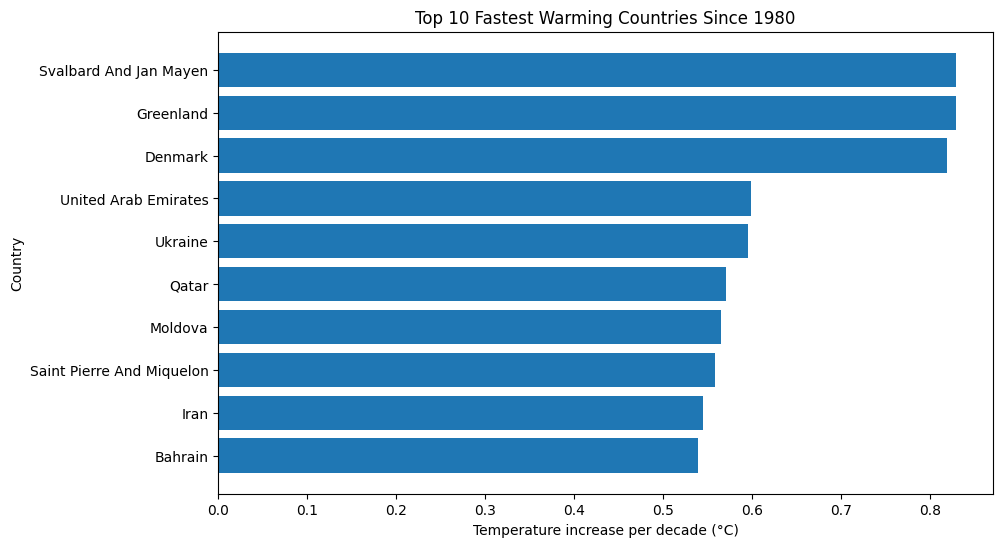

In [149]:
import matplotlib.pyplot as plt

top10 = top_warming_countries

plt.figure(figsize=(10,6))

plt.barh(
    top10["Country"],
    top10["Slope_per_decade"]
)

plt.xlabel("Temperature increase per decade (°C)")
plt.ylabel("Country")
plt.title("Top 10 Fastest Warming Countries Since 1980")

plt.gca().invert_yaxis()

plt.show()

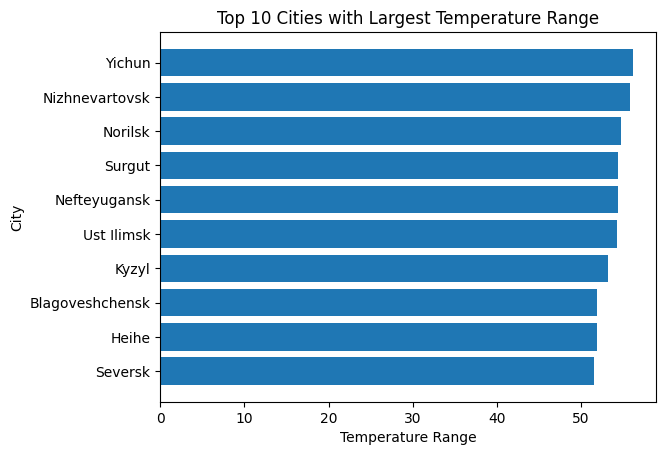

In [55]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_variable["City"], top_variable["range"])
plt.xlabel("Temperature Range")
plt.ylabel("City")
plt.title("Top 10 Cities with Largest Temperature Range")
plt.gca().invert_yaxis()
plt.show()

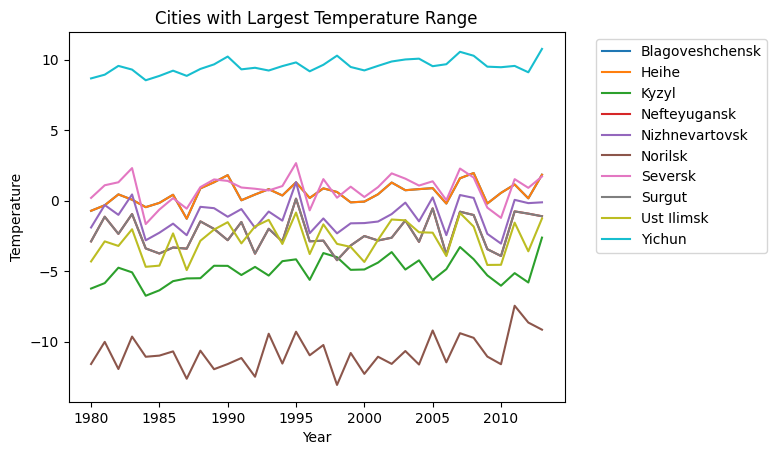

In [56]:
import matplotlib.pyplot as plt

subset = city_yearly[
    city_yearly["City"].isin(top_variable["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("Cities with Largest Temperature Range")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [57]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByMajorCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_major_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_major_city_subset.shape)
print(df_major_city_subset["Country"].nunique())
print(df_major_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_major_city_subset["AverageTemperature"] = (
    df_major_city_subset["AverageTemperature"]
    .fillna(df_major_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_major_city_subset
    .groupby("City", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_major_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_major_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_major_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_major_cold_city)

(239177, 7)
(40500, 7)
49
100
Top 10 Hottest Cities:
                City  AverageTemperature
97        Umm Durman           29.652307
57            Madras           29.041574
42            Jiddah           28.242493
35  Ho Chi Minh City           27.770054
8            Bangkok           27.765322
63         Mogadishu           27.672478
30         Fortaleza           27.638399
36         Hyderabad           27.477592
87          Surabaya           27.412795
75           Rangoon           27.332765

Top 10 Coldest Cities:
                City  AverageTemperature
34            Harbin            4.732978
79  Saint Petersburg            4.922995
65            Moscow            5.170673
64          Montreal            5.569536
19         Changchun            5.984960
81          Santiago            6.297983
96           Toronto            6.807879
48              Kiev            8.042911
85          Shenyang            8.153666
92           Taiyuan            8.801297


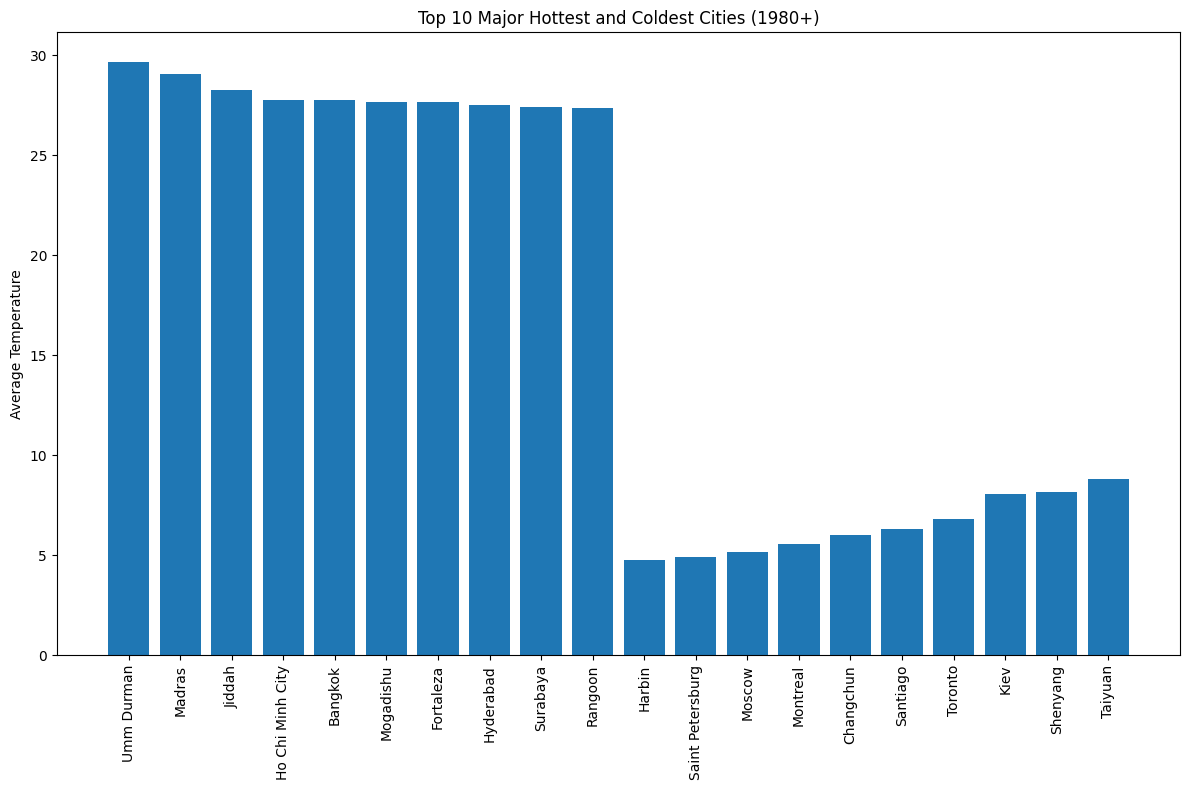

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_major_hot_city["Type"] = "Hottest"
top_major_cold_city["Type"] = "Coldest"
combined = pd.concat([top_major_hot_city, top_major_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Major Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

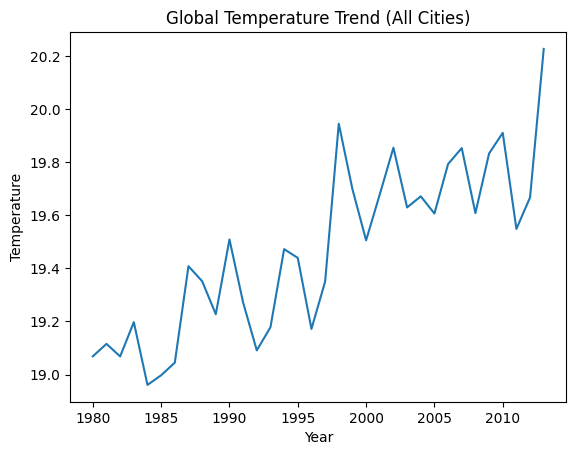

In [59]:
df_major_city_subset["year"] = df_major_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_major_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [60]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalTemperatures.csv")

# 2. Clean columns
# 1. Date
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

# 2. Numeric columns
cols = [
    "LandAverageTemperature",
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperature",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperature",
    "LandMinTemperatureUncertainty",
    "LandAndOceanAverageTemperature",
    "LandAndOceanAverageTemperatureUncertainty"
]

for col in cols:
       df[col] = pd.to_numeric(df[col], errors="coerce")


In [61]:

df[cols].describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


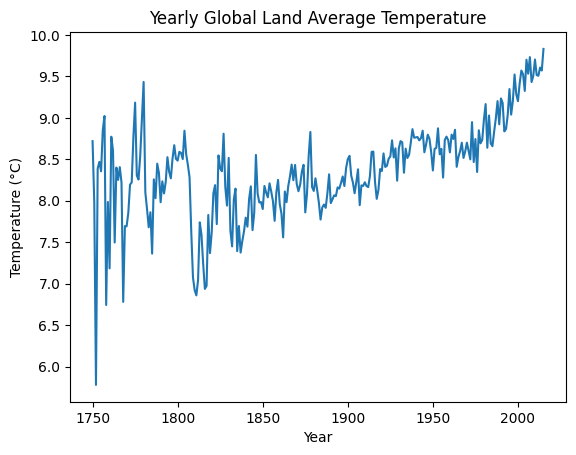

In [62]:
import matplotlib.pyplot as plt

# Create year column
df["year"] = df["dt"].dt.year

# Group by year (global average)
yearly = (
    df.groupby("year")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.figure()
plt.plot(yearly["year"], yearly["LandAverageTemperature"])

plt.title("Yearly Global Land Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [116]:
before_1980 = yearly[yearly["year"] < 1980]
after_1980 = yearly[yearly["year"] >= 1980]

In [117]:
print("Before 1980 average temperature:")
print(before_1980["LandAverageTemperature"].mean())

print("After 1980 average temperature:")
print(after_1980["LandAverageTemperature"].mean())

Before 1980 average temperature:
8.2300148833051
After 1980 average temperature:
9.25945138888889


In [121]:
import numpy as np

slope_before = np.polyfit(
    before_1980["year"],
    before_1980["LandAverageTemperature"],
    1
)[0]

trend_before = np.poly1d(slope_before)

slope_after = np.polyfit(
    after_1980["year"],
    after_1980["LandAverageTemperature"],
    1
)[0]

trend_after = np.poly1d(slope_after)

print("Slope before 1980:", slope_before)
print("Slope after 1980:", slope_after)

Slope before 1980: 0.0030143144229904826
Slope after 1980: 0.02654430501930498


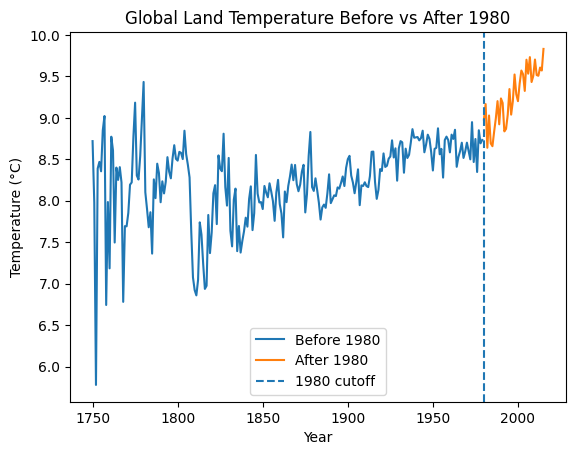

In [122]:
plt.figure()

plt.plot(before_1980["year"], before_1980["LandAverageTemperature"], label="Before 1980")
plt.plot(after_1980["year"], after_1980["LandAverageTemperature"], label="After 1980")

plt.axvline(1980, linestyle="--", label="1980 cutoff")

plt.title("Global Land Temperature Before vs After 1980")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

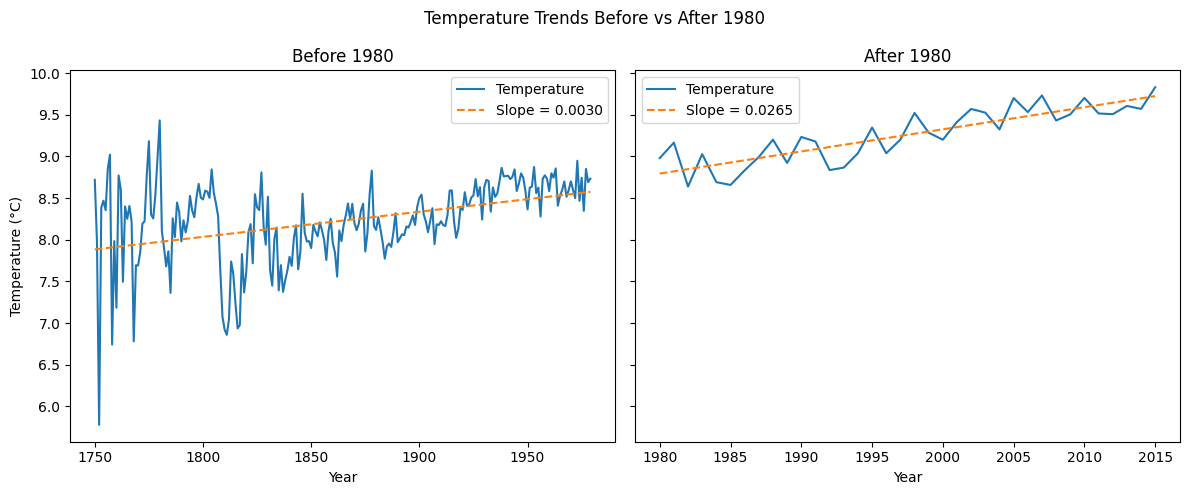

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Split data
before_1980 = yearly[yearly["year"] < 1980]
after_1980 = yearly[yearly["year"] >= 1980]

# Fit trend lines
coef_before = np.polyfit(before_1980["year"], before_1980["LandAverageTemperature"], 1)
coef_after = np.polyfit(after_1980["year"], after_1980["LandAverageTemperature"], 1)

trend_before = np.poly1d(coef_before)
trend_after = np.poly1d(coef_after)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Before 1980 plot
axes[0].plot(before_1980["year"], before_1980["LandAverageTemperature"], label="Temperature")
axes[0].plot(
    before_1980["year"],
    trend_before(before_1980["year"]),
    linestyle="--",
    label=f"Slope = {coef_before[0]:.4f}"
)
axes[0].set_title("Before 1980")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# After 1980 plot
axes[1].plot(after_1980["year"], after_1980["LandAverageTemperature"], label="Temperature")
axes[1].plot(
    after_1980["year"],
    trend_after(after_1980["year"]),
    linestyle="--",
    label=f"Slope = {coef_after[0]:.4f}"
)
axes[1].set_title("After 1980")
axes[1].set_xlabel("Year")
axes[1].legend()

# Final layout
plt.suptitle("Temperature Trends Before vs After 1980")
plt.tight_layout()
plt.show()

In [63]:
# Make sure year exists
df["year"] = df["dt"].dt.year

# Create century (e.g. 1750 → 18th century)
df["century"] = (df["year"] // 100) + 1

In [64]:
century_avg = (
    df.groupby("century")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

print(century_avg)

   century  LandAverageTemperature
0       18                8.203032
1       19                8.009105
2       20                8.637712
3       21                9.542094


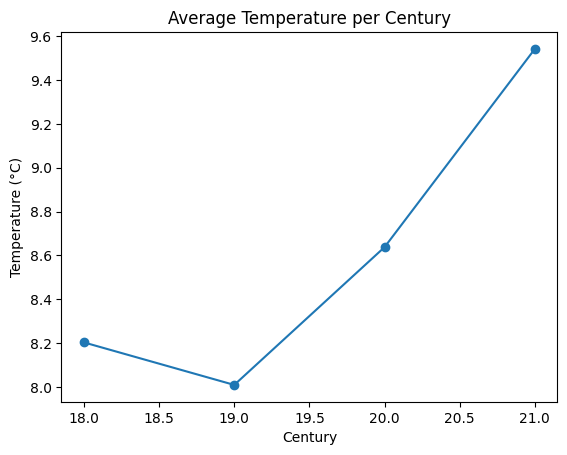

In [65]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(century_avg["century"], century_avg["LandAverageTemperature"], marker="o")

plt.title("Average Temperature per Century")
plt.xlabel("Century")
plt.ylabel("Temperature (°C)")

plt.show()

In [66]:
# Describe uncertainty columns
uncertainty_cols = [
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperatureUncertainty",
    "LandAndOceanAverageTemperatureUncertainty"
]

print(df[uncertainty_cols].describe())

       LandAverageTemperatureUncertainty  LandMaxTemperatureUncertainty  \
count                        3180.000000                    1992.000000   
mean                            0.938468                       0.479782   
std                             1.096440                       0.583203   
min                             0.034000                       0.044000   
25%                             0.186750                       0.142000   
50%                             0.392000                       0.252000   
75%                             1.419250                       0.539000   
max                             7.880000                       4.373000   

       LandMinTemperatureUncertainty  \
count                    1992.000000   
mean                        0.431849   
std                         0.445838   
min                         0.045000   
25%                         0.155000   
50%                         0.279000   
75%                         0.458250   
max 

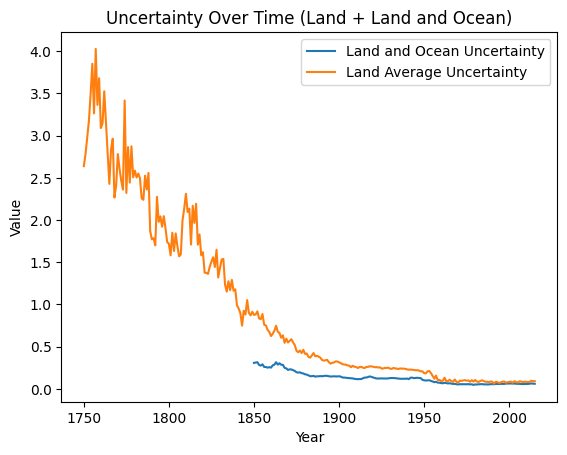

In [67]:
df["year"] = df["dt"].dt.year

trend = (
    df.groupby("year")[[
        "LandAndOceanAverageTemperatureUncertainty",
        "LandAverageTemperatureUncertainty"
    ]]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()

# Temperature line
plt.plot(
    trend["year"],
    trend["LandAndOceanAverageTemperatureUncertainty"],
    label="Land and Ocean Uncertainty"
)

# Uncertainty line
plt.plot(
    trend["year"],
    trend["LandAverageTemperatureUncertainty"],
    label="Land Average Uncertainty"
)

plt.title("Uncertainty Over Time (Land + Land and Ocean)")
plt.xlabel("Year")
plt.ylabel("Value")

plt.legend()
plt.show()

In [69]:
highest_uncertainty = trend.sort_values(
    "LandAverageTemperatureUncertainty", ascending=False
).head(10)

print(highest_uncertainty)

    year  LandAndOceanAverageTemperatureUncertainty  \
7   1757                                        NaN   
5   1755                                        NaN   
9   1759                                        NaN   
12  1762                                        NaN   
4   1754                                        NaN   
24  1774                                        NaN   
8   1758                                        NaN   
6   1756                                        NaN   
3   1753                                        NaN   
13  1763                                        NaN   

    LandAverageTemperatureUncertainty  
7                            4.026000  
5                            3.850333  
9                            3.678917  
12                           3.524250  
4                            3.494250  
24                           3.415167  
8                            3.362917  
6                            3.262333  
3                            3.176

In [70]:
def convert_coord(coord):
    coord = str(coord).strip()
    if coord[-1] in ["N", "E"]:
        return float(coord[:-1])
    elif coord[-1] in ["S", "W"]:
        return -float(coord[:-1])
    else:
        return None

df_city_subset["lat"] = df_city_subset["Latitude"].apply(convert_coord)
df_city_subset["lon"] = df_city_subset["Longitude"].apply(convert_coord)

In [75]:
city_avg = (
    df_city_subset.groupby(["City", "Country", "lat", "lon"])["AverageTemperature"]
    .mean()
    .reset_index()
)

In [72]:
import pandas as pd
import plotly.express as px

fig = px.scatter_geo(
    city_avg,
    lat="lat",
    lon="lon",
    color="AverageTemperature",
    hover_name="City",
    hover_data=["Country", "AverageTemperature"],
    title="Average Temperature per City",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

In [76]:


top_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

top_hot_city["Type"] = "Hottest"
top_cold_city["Type"] = "Coldest"

extremes = pd.concat([top_hot_city, top_cold_city])

In [79]:
extremes_variable = pd.concat([top_variable, bottom_variable])

city_map = city_avg.merge(
    extremes_variable[["City", "range"]],
    on="City",
    how="inner"
)

In [83]:
def convert_lat(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == "N" else -1)
    return val

def convert_lon(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == "E" else -1)
    return val

city_map["lat"] = city_map["lat"].apply(convert_lat)
city_map["lon"] = city_map["lon"].apply(convert_lon)


fig = px.scatter_geo(
    city_map,
    lat="lat",
    lon="lon",
    color="range",  # 👈 THIS is the key change
    size="range",   # 👈 makes differences visible
    hover_name="City",
    hover_data=["City", "AverageTemperature", "range"],
    title="Temperature Range per City",
    color_continuous_scale="Viridis"
)

fig.show()

In [85]:
def convert_lat(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == 'N' else -1)
    return val  # already numeric

def convert_lon(val):
    if isinstance(val, str):
        return float(val[:-1]) * (1 if val[-1] == 'E' else -1)
    return val  # already numeric

extremes["lat"] = extremes["lat"].apply(convert_lat)
extremes["lon"] = extremes["lon"].apply(convert_lon)

fig = px.scatter_geo(
    extremes,
    lat="lat",
    lon="lon",
    color="AverageTemperature",
    hover_name="City",
    hover_data=["City", "AverageTemperature"],
    title="Top 10 Hottest and Coldest Cities",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

In [86]:
top_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)

selected_countries = pd.concat([top_hot, top_cold])

fig = px.choropleth(
    selected_countries,
    locations="Country",
    locationmode="country names",
    color="AverageTemperature",
    hover_name="Country",
    title="Hottest and Coldest Countries",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/1867658377.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [87]:
# 👉 THIS is what you want
country_avg = (
    df_subset
    .groupby("Country")["AverageTemperature"]
    .mean()
    .reset_index()
)

print(country_avg)

            Country  AverageTemperature
0       Afghanistan           14.963869
1            Africa           24.690864
2           Albania           13.233686
3           Algeria           23.870874
4    American Samoa           27.107718
..              ...                 ...
238  Western Sahara           23.182146
239           Yemen           26.837510
240          Zambia           21.853948
241        Zimbabwe           21.695399
242           Åland            6.149498

[243 rows x 2 columns]


In [88]:
import plotly.express as px

fig = px.choropleth(
    country_avg,
    locations="Country",
    locationmode="country names",
    color="AverageTemperature",
    hover_name="Country",
    title="Average Temperature per Country (All Countries)",
    color_continuous_scale=["blue", "green", "red"]
)

fig.show()



/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/1308043973.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [89]:
import pandas as pd

df = pd.read_csv(
    "/Applications/XAMPP/xamppfiles/htdocs/climate-watch/co2 data/GHG_totals_by_country-Tabel 1.csv",
    sep=";",
    skiprows=1
)

# Fix weird column names
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()

# Force correct names
df.columns = ["EDGAR Country Code", "Country"] + list(df.columns[2:])

# Melt (wide → long)
df_long = df.melt(
    id_vars=["Country"],
    var_name="year",
    value_name="co2"
)

# Clean values
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")

df_long["co2"] = (
    df_long["co2"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_long["co2"] = pd.to_numeric(df_long["co2"], errors="coerce")

# Filter years
df_long = df_long[df_long["year"] >= 1980]

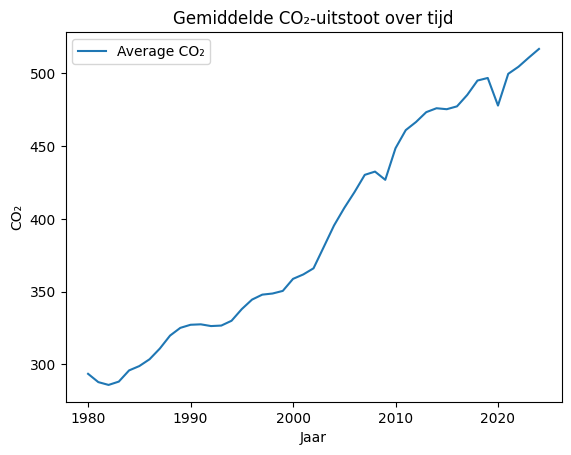

In [90]:
co2_yearly = (
    df_long
    .groupby("year")["co2"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    co2_yearly["year"],
    co2_yearly["co2"],
    label="Average CO₂"
)

plt.title("Gemiddelde CO₂-uitstoot over tijd")
plt.xlabel("Jaar")
plt.ylabel("CO₂")

plt.legend()
plt.show()

In [129]:
merged = yearly.merge(co2_yearly, on="year", how="inner")

In [138]:
corr = merged["LandAverageTemperature"].corr(merged["co2"])
print("Correlation:", corr)

Correlation: 0.8369987025642812


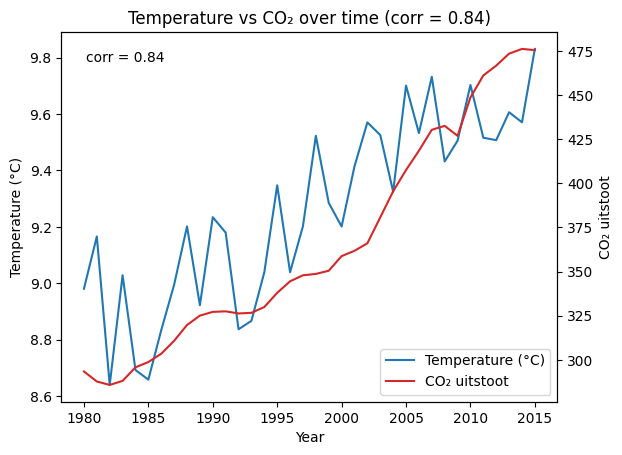

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Temperature (left axis)
ax1.plot(
    merged["year"],
    merged["LandAverageTemperature"],
    label="Temperature (°C)",
    color="tab:blue"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature (°C)")

# CO2 (right axis)
ax2 = ax1.twinx()
ax2.plot(
    merged["year"],
    merged["co2"],
    label="CO₂ uitstoot",
    color="tab:red"
)
ax2.set_ylabel("CO₂ uitstoot")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

# Add correlation to title
plt.title(f"Temperature vs CO₂ over time")

ax1.text(
    0.05, 0.95,
    f"corr = {corr:.2f}",
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top"
)



plt.show()

In [131]:
print(merged.columns)

Index(['year', 'LandAverageTemperature', 'co2'], dtype='str')


Correlation: 0.8369987025642812


In [93]:
import pandas as pd

file_path = "/Applications/XAMPP/xamppfiles/htdocs/climate-watch/co2 data/PovStatsData 2.csv"

# Skip first title row, use row 2 as column names
df = pd.read_csv(
    file_path,
    sep=";",
    skiprows=1
)

# Clean country column
df["Country Name"] = df["Country Name"].astype(str).str.strip()

# Find Afghanistan
start_index = df[df["Country Name"] == "Afghanistan"].index[0]

# Keep from Afghanistan onward
df_clean = df.loc[start_index:].copy()
df_clean.reset_index(drop=True, inplace=True)

# Save cleaned CSV
df_clean.to_csv("cleaned_povstats.csv", index=False)

print(df_clean.head())
print(df_clean.columns)

  Country Name Country Code  \
0  Afghanistan          AFG   
1  Afghanistan          AFG   
2  Afghanistan          AFG   
3  Afghanistan          AFG   
4  Afghanistan          AFG   

                                      Indicator Name  Indicator Code  1974  \
0  Annualized growth in per capita real survey me...  SI.SPR.PC40.ZG   NaN   
1  Annualized growth in per capita real survey me...  SI.SPR.PT10.ZG   NaN   
2  Annualized growth in per capita real survey me...  SI.SPR.PT60.ZG   NaN   
3  Annualized growth in per capita real survey me...  SI.SPR.PCAP.ZG   NaN   
4                   GINI index (World Bank estimate)     SI.POV.GINI   NaN   

   1975  1976  1977  1978  1979  ...  2010  2011  2012  2013  2014  2015  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
2   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
3   NaN   NaN   NaN   NaN   NaN  ...   N

In [94]:
indicators = [
    "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)",
    "GINI index (World Bank estimate)",
    "Number of poor at $1.90 a day (2011 PPP) (millions)"
]

df_filtered = df_clean[df_clean["Indicator Name"].isin(indicators)].copy()


In [95]:
df_long = df_filtered.melt(
    id_vars=["Country Name", "Indicator Name"],
    var_name="year",
    value_name="value"
)

In [96]:
df_long["value"] = (
    df_long["value"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .replace("..", pd.NA)
)

df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

In [97]:
# Convert year to numeric
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")

# Convert values to numeric
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

# Drop missing
df_long = df_long.dropna(subset=["year", "value"])

In [98]:
df_pivot = df_long.pivot_table(
    index=["Country Name", "year"],
    columns="Indicator Name",
    values="value"
).reset_index()

In [99]:
df_global = df_pivot.groupby("year", as_index=False).mean(numeric_only=True)

In [100]:
df_pivot["year"] = df_pivot["year"].astype(int)
df_global["year"] = df_global["year"].astype(int)

In [101]:
print(df_pivot.dtypes)

Indicator Name
Country Name                                                               str
year                                                                     int64
GINI index (World Bank estimate)                                       float64
Number of poor at $1.90 a day (2011 PPP) (millions)                    float64
Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)    float64
dtype: object


In [151]:
poverty_wide = df_long.pivot_table(
    index=["Country Name", "year"],
    columns="Indicator Name",
    values="value"
).reset_index()

poverty_wide.columns.name = None

In [164]:
sorted(poverty_wide["year"].dropna().unique())

[np.float64(1977.0),
 np.float64(1979.0),
 np.float64(1980.0),
 np.float64(1981.0),
 np.float64(1982.0),
 np.float64(1983.0),
 np.float64(1984.0),
 np.float64(1985.0),
 np.float64(1986.0),
 np.float64(1987.0),
 np.float64(1988.0),
 np.float64(1989.0),
 np.float64(1990.0),
 np.float64(1991.0),
 np.float64(1992.0),
 np.float64(1993.0),
 np.float64(1994.0),
 np.float64(1995.0),
 np.float64(1996.0),
 np.float64(1997.0),
 np.float64(1998.0),
 np.float64(1999.0),
 np.float64(2000.0),
 np.float64(2001.0),
 np.float64(2002.0),
 np.float64(2003.0),
 np.float64(2004.0),
 np.float64(2005.0),
 np.float64(2006.0),
 np.float64(2007.0),
 np.float64(2008.0),
 np.float64(2009.0),
 np.float64(2010.0),
 np.float64(2011.0),
 np.float64(2012.0),
 np.float64(2013.0),
 np.float64(2014.0),
 np.float64(2015.0),
 np.float64(2016.0),
 np.float64(2017.0)]

In [154]:
poverty_recent = poverty_wide[
    poverty_wide["year"] == 2017
].copy()

print(poverty_recent.head())

    Country Name    year  GINI index (World Bank estimate)  \
38     Argentina  2017.0                              40.6   
56       Armenia  2017.0                              33.6   
114      Belarus  2017.0                              25.4   
140       Bhutan  2017.0                              37.4   
159      Bolivia  2017.0                              44.0   

     Number of poor at $1.90 a day (2011 PPP) (millions)  \
38                                                 0.2     
56                                                 0.0     
114                                                0.0     
140                                                0.0     
159                                                0.6     

     Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)  
38                                                 0.4                    
56                                                 1.4                    
114                                      

In [165]:
poverty_recent = poverty_recent[
    [
        "Country Name",
        "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)"
    ]
]

In [166]:
poverty_recent = poverty_recent.rename(columns={
    "Country Name": "Country",
    "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)": "Poverty_Rate"
})

In [167]:
poverty_recent.isna().sum()

Country         0
Poverty_Rate    0
dtype: int64

In [169]:
country_slope_df["Country"] = (
    country_slope_df["Country"]
    .astype(str)
    .str.strip()
)

poverty_recent["Country"] = (
    poverty_recent["Country"]
    .astype(str)
    .str.strip()
)

In [185]:
temp_countries = set(country_slope_df["Country"])
poverty_countries = set(poverty_recent["Country"])

missing_in_poverty = temp_countries - poverty_countries
missing_in_temp = poverty_countries - temp_countries

print(missing_in_poverty)
print(missing_in_temp)

{'French Polynesia', 'Åland', 'Senegal', 'Taiwan', 'Angola', 'Tanzania', 'Macau', 'Trinidad And Tobago', 'Guadeloupe', 'Sao Tome And Principe', 'Christmas Island', 'Montserrat', 'Grenada', 'Svalbard And Jan Mayen', 'Switzerland', 'Turkmenistan', 'Puerto Rico', 'Azerbaijan', 'Aruba', 'Gaza Strip', 'Cape Verde', 'Guyana', 'Solomon Islands', 'Tonga', 'Russia', 'Singapore', 'Israel', 'Madagascar', 'Sierra Leone', 'Namibia', 'Egypt', 'Slovenia', 'Liberia', 'Sweden', 'Kingman Reef', 'Sri Lanka', 'Malaysia', 'Netherlands', 'Haiti', 'Libya', 'Cameroon', 'North America', 'Mexico', 'Nepal', 'Australia', 'Ghana', 'Kiribati', 'Falkland Islands (Islas Malvinas)', 'Liechtenstein', 'Europe', 'Cuba', 'Canada', 'Algeria', 'Romania', 'Timor Leste', 'Zambia', 'Iran', 'Bonaire, Saint Eustatius And Saba', 'Sint Maarten', 'South Korea', 'South America', 'Ukraine', 'Hong Kong', 'Sudan', 'Saint Barthélemy', 'Malta', 'Andorra', 'New Caledonia', 'France', 'Greece', 'Papua New Guinea', 'Yemen', 'Morocco', 'Saint

In [186]:
poverty_recent[["Country", "Poverty_Rate"]].dropna().shape

(25, 2)

In [187]:
poverty_col = "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)"

poverty_latest = (
    poverty_wide[["Country Name", "year", poverty_col]]
    .dropna(subset=[poverty_col])
    .sort_values(["Country Name", "year"])
    .groupby("Country Name")
    .tail(1)
    .rename(columns={
        "Country Name": "Country",
        poverty_col: "Poverty_Rate"
    })
)

poverty_latest.head()
poverty_latest["Country"].nunique()

164

In [188]:
merged_df = pd.merge(
    country_slope_df,
    poverty_latest,
    on="Country",
    how="inner"
)

merged_df["Country"].nunique()

133

In [189]:
import plotly.express as px

fig = px.choropleth(
    merged_df,
    locations="Country",
    locationmode="country names",
    color="Poverty_Rate",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Current Poverty Levels by Country"
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/995681184.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


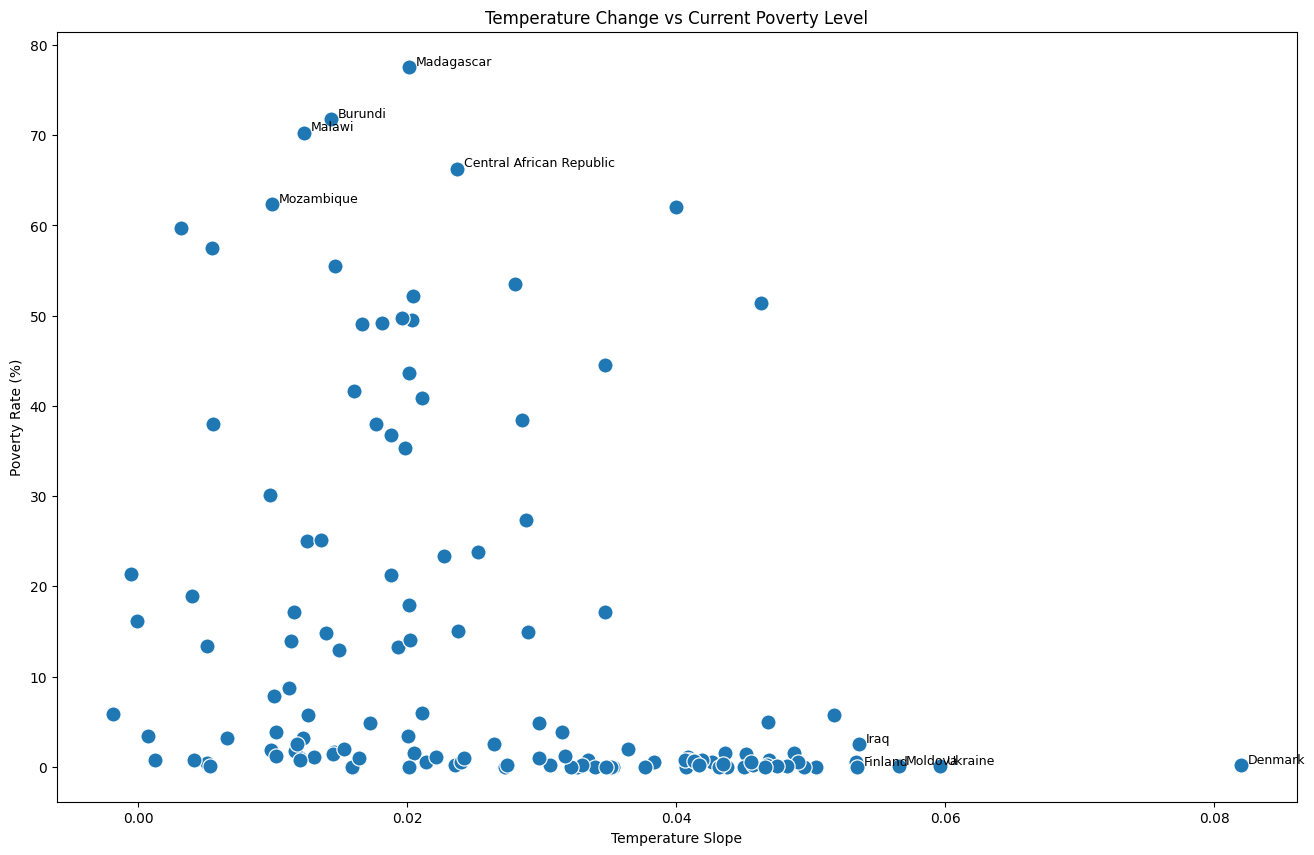

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(16,10))

sns.scatterplot(
    data=merged_df,
    x="Slope_per_year",
    y="Poverty_Rate",
    s=120
)

# Top warming countries
top_warming = merged_df.nlargest(5, "Slope_per_year")

# Top poverty countries
top_poverty = merged_df.nlargest(5, "Poverty_Rate")

# Combine them and remove duplicates
top_countries = pd.concat(
    [top_warming, top_poverty]
).drop_duplicates()

# Add labels
for i, row in top_countries.iterrows():
    plt.text(
        row["Slope_per_year"] + 0.0005,
        row["Poverty_Rate"] + 0.2,
        row["Country"],
        fontsize=9
    )

plt.title("Temperature Change vs Current Poverty Level")
plt.xlabel("Temperature Slope")
plt.ylabel("Poverty Rate (%)")

plt.show()

In [238]:
merged_df["Poverty_Rate"].corr(merged_df["Slope_per_year"])

np.float64(-0.31752168130445835)

In [192]:
fig = px.choropleth(
    merged_df,
    locations="Country",
    locationmode="country names",
    color="Slope_per_decade",
    hover_name="Country",
    color_continuous_scale="RdYlBu_r",
    title="Temperature Change per Decade by Country"
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/3815288109.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [170]:
merged_df = pd.merge(
    country_slope_df,
    poverty_recent,
    on="Country",
    how="inner"
)

In [193]:
poverty_trend = poverty_wide[
    ["Country Name", "year", poverty_col]
].copy()

In [194]:
poverty_trend = poverty_trend.dropna(subset=[poverty_col])

In [195]:
import numpy as np
import pandas as pd

poverty_slopes = []

for country in poverty_trend["Country Name"].unique():

    country_data = poverty_trend[
        poverty_trend["Country Name"] == country
    ]

    # Ensure enough years
    if len(country_data) > 5:

        slope = np.polyfit(
            country_data["year"],
            country_data[poverty_col],
            1
        )[0]

        poverty_slopes.append({
            "Country": country,
            "Poverty_Slope": slope
        })

poverty_slope_df = pd.DataFrame(poverty_slopes)

In [196]:
poverty_slope_df.sort_values(
    by="Poverty_Slope"
).head(10)

,Country,Poverty_Slope
83,Tajikistan,-2.986150
14,China,-2.592042
93,Vietnam,-2.331025
38,Indonesia,-2.238384
47,Kyrgyz Republic,-2.149616
65,Pakistan,-1.970003
56,Moldova,-1.661688
61,Nicaragua,-1.566820
62,Niger,-1.483285
33,Guatemala,-1.408902


In [197]:
merged_slopes = pd.merge(
    country_slope_df,
    poverty_slope_df,
    on="Country",
    how="inner"
)

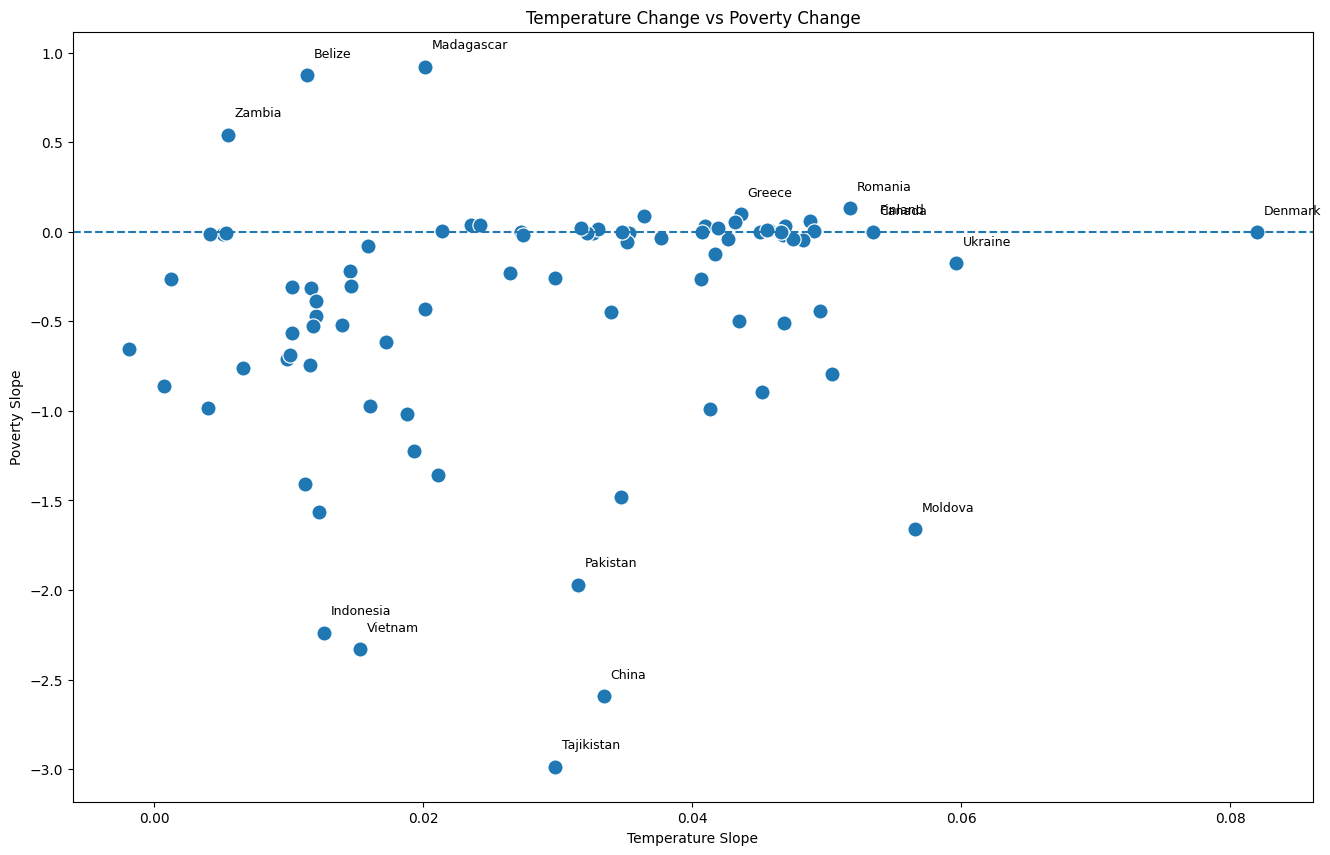

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(16,10))

sns.scatterplot(
    data=merged_slopes,
    x="Slope_per_year",
    y="Poverty_Slope",
    s=120
)

# Largest warming
top_warming = merged_slopes.nlargest(5, "Slope_per_year")

# Largest poverty reduction
top_reduction = merged_slopes.nsmallest(5, "Poverty_Slope")

# Largest poverty increase
top_increase = merged_slopes.nlargest(5, "Poverty_Slope")

# Combine all labels
label_df = pd.concat([
    top_warming,
    top_reduction,
    top_increase
]).drop_duplicates()

# Add labels
for i, row in label_df.iterrows():
    plt.text(
        row["Slope_per_year"] + 0.0005,
        row["Poverty_Slope"] + 0.1,
        row["Country"],
        fontsize=9
    )

plt.title("Temperature Change vs Poverty Change")
plt.xlabel("Temperature Slope")
plt.ylabel("Poverty Slope")

plt.axhline(0, linestyle="--")
plt.show()

In [239]:
merged_slopes["Slope_per_year"].corr(merged_slopes["Poverty_Slope"])

np.float64(0.19430366509394761)

In [200]:
import plotly.express as px

fig = px.choropleth(
    merged_slopes,
    locations="Country",
    locationmode="country names",
    color="Poverty_Slope",
    hover_name="Country",
    color_continuous_scale="RdYlGn_r",
    title="Poverty Change by Country"
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/957212153.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [203]:
from scipy.stats import linregress

result = linregress(
    merged_slopes["Slope_per_year"],
    merged_slopes["Poverty_Slope"]
)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: 7.882964363225848
Intercept: -0.6519860562314646
R-squared: 0.03775391426894093
P-value: 0.07302768536956267


In [204]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(
            country_name,
            cn_name_format="default"
        )

        continent_code = pc.country_alpha2_to_continent_code(country_code)

        continents = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
        }

        return continents[continent_code]

    except:
        return "Unknown"

merged_slopes["Region"] = merged_slopes["Country"].apply(country_to_continent)

In [205]:
print(merged_slopes["Region"].value_counts())

Region
Europe           34
Asia             20
North America    12
Africa           10
South America     9
Oceania           1
Name: count, dtype: int64


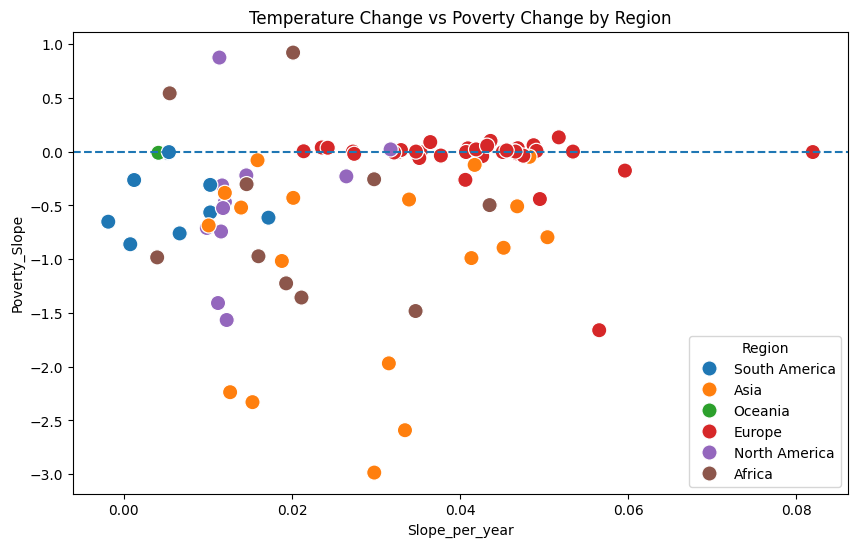

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_slopes,
    x="Slope_per_year",
    y="Poverty_Slope",
    hue="Region",
    s=120
)

plt.axhline(0, linestyle="--")
plt.title("Temperature Change vs Poverty Change by Region")

plt.show()

In [210]:
countries = sorted(merged_slopes["Country"].unique())

print(countries)

['Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Jordan', 'Kazakhstan', 'Latvia', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mauritania', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Netherlands', 'Nicaragua', 'Niger', 'Norway', 'Pakistan', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Rwanda', 'Serbia', 'Slovenia', 'South Africa', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Tajikistan', 'Thailand', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 'United Kingdom', 'United States', 'Uruguay', 'Vietnam'

In [211]:
developed = [
    'Australia',
    'Austria',
    'Belgium',
    'Canada',
    'Cyprus',
    'Czech Republic',
    'Denmark',
    'Estonia',
    'Finland',
    'France',
    'Germany',
    'Greece',
    'Iceland',
    'Ireland',
    'Israel',
    'Italy',
    'Latvia',
    'Lithuania',
    'Luxembourg',
    'Malta',
    'Netherlands',
    'Norway',
    'Poland',
    'Portugal',
    'Slovenia',
    'Spain',
    'Sweden',
    'Switzerland',
    'United Kingdom',
    'United States'
]

merged_slopes["Development_Status"] = (
    merged_slopes["Country"]
    .apply(lambda x: "Developed" if x in developed else "Developing")
)

In [212]:
merged_slopes[
    ["Country", "Development_Status"]
].sort_values("Development_Status")

,Country,Development_Status
25,Finland,Developed
64,Poland,Developed
65,Portugal,Developed
30,Greece,Developed
37,Ireland,Developed
...,...,...
47,Malaysia,Developing
49,Mauritania,Developing
50,Mexico,Developing
23,El Salvador,Developing


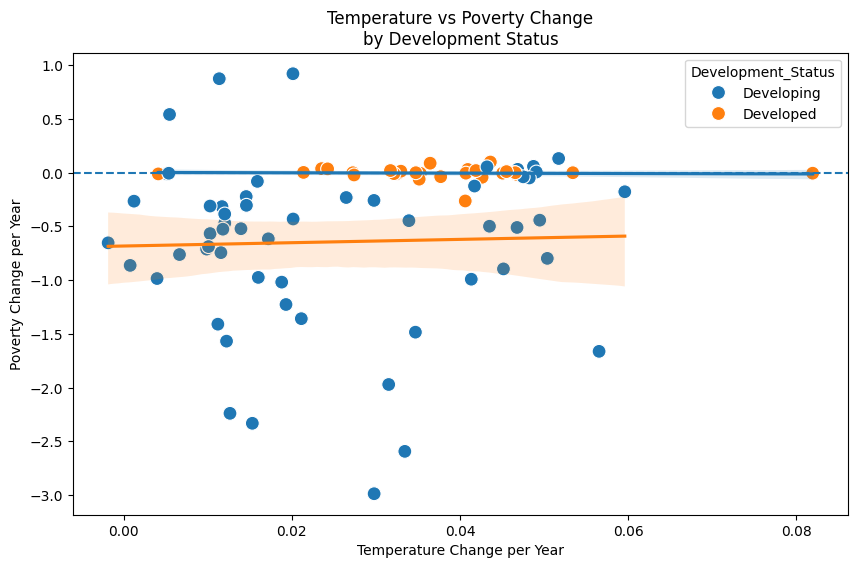

In [213]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_slopes,
    x="Slope_per_year",
    y="Poverty_Slope",
    hue="Development_Status",
    s=100
)

sns.regplot(
    data=merged_slopes[
        merged_slopes["Development_Status"] == "Developed"
    ],
    x="Slope_per_year",
    y="Poverty_Slope",
    scatter=False
)

sns.regplot(
    data=merged_slopes[
        merged_slopes["Development_Status"] == "Developing"
    ],
    x="Slope_per_year",
    y="Poverty_Slope",
    scatter=False
)

plt.axhline(0, linestyle="--")

plt.xlabel("Temperature Change per Year")
plt.ylabel("Poverty Change per Year")

plt.title(
    "Temperature vs Poverty Change\nby Development Status"
)

plt.show()

In [226]:
import pandas as pd

forest_df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/co2 data/global_deforestation_2000_2025.csv",sep=";",skiprows=1)

In [227]:
forest_df.info()
forest_df.isna().sum()
print(forest_df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 5720 entries, 0 to 5719
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    5720 non-null   str    
 1   Year                       5720 non-null   int64  
 2   Forest_Area_km2            5720 non-null   int64  
 3   Land_Area_km2              5720 non-null   int64  
 4   Forest_Cover_Pct           5720 non-null   float64
 5   Annual_Deforestation_Rate  5720 non-null   float64
 6   Annual_Afforestation_Rate  5720 non-null   float64
 7   Total_Carbon_Stock_Tonnes  5720 non-null   int64  
 8   Primary_Driver_of_Change   1344 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 402.3 KB
Index(['Country', 'Year', 'Forest_Area_km2', 'Land_Area_km2',
       'Forest_Cover_Pct', 'Annual_Deforestation_Rate',
       'Annual_Afforestation_Rate', 'Total_Carbon_Stock_Tonnes',
       'Primary_Driver_of_Change'],
      dtyp

In [228]:
from scipy.stats import linregress

slopes = []

for country in forest_df["Country"].unique():

    country_df = forest_df[
        forest_df["Country"] == country
    ]

    result = linregress(
        country_df["Year"],
        country_df["Annual_Deforestation_Rate"]
    )

    slopes.append({
        "Country": country,
        "Deforestation_Slope": result.slope
    })

deforestation_slopes = pd.DataFrame(slopes)

In [229]:
merged_all = merged_slopes.merge(
    deforestation_slopes,
    on="Country",
    how="inner"
)

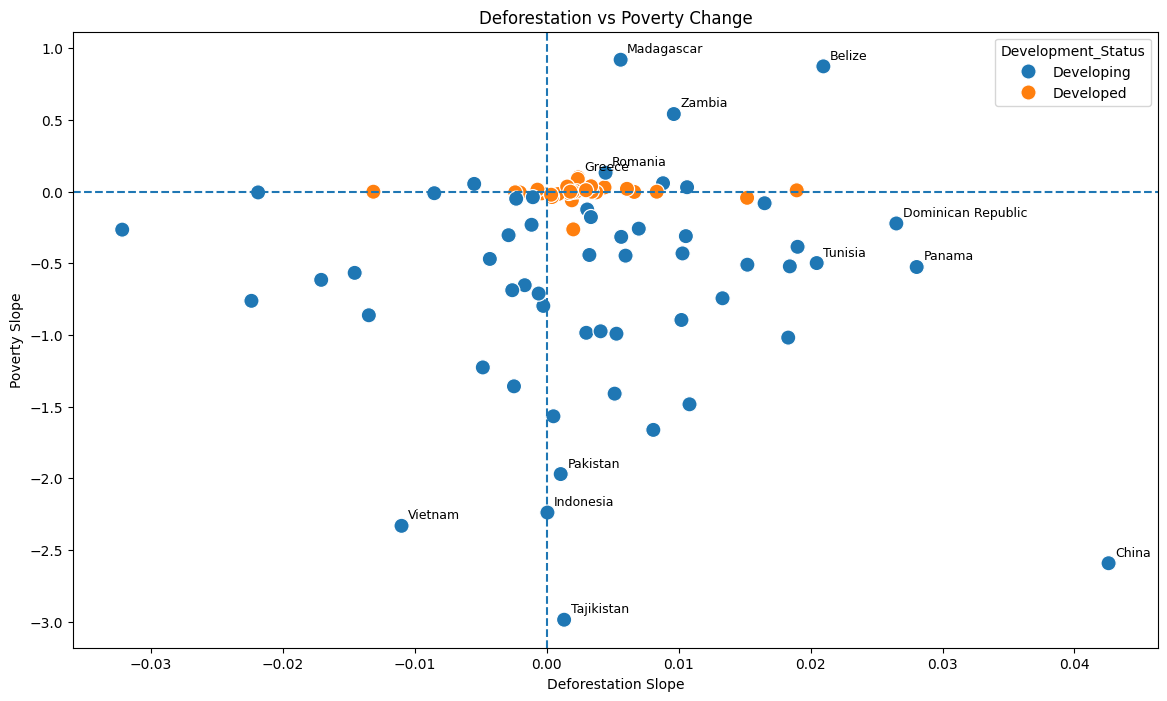

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,8))

sns.scatterplot(
    data=merged_all,
    x="Deforestation_Slope",
    y="Poverty_Slope",
    hue="Development_Status",
    s=120
)

# Largest deforestation increase
top_deforestation = merged_all.nlargest(5, "Deforestation_Slope")

# Largest poverty decrease
top_poverty_decrease = merged_all.nsmallest(5, "Poverty_Slope")

# Largest poverty increase
top_poverty_increase = merged_all.nlargest(5, "Poverty_Slope")

# Combine labels
label_df = pd.concat([
    top_deforestation,
    top_poverty_decrease,
    top_poverty_increase
]).drop_duplicates()

# Add country labels
for i, row in label_df.iterrows():
    plt.text(
        row["Deforestation_Slope"] + 0.0005,
        row["Poverty_Slope"] + 0.05,
        row["Country"],
        fontsize=9
    )

plt.title("Deforestation vs Poverty Change")
plt.xlabel("Deforestation Slope")
plt.ylabel("Poverty Slope")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.show()

In [241]:
merged_all["Deforestation_Slope"].corr(merged_all["Poverty_Slope"])

np.float64(-0.04311219103596164)

<Axes: xlabel='Slope_per_year', ylabel='Deforestation_Slope'>

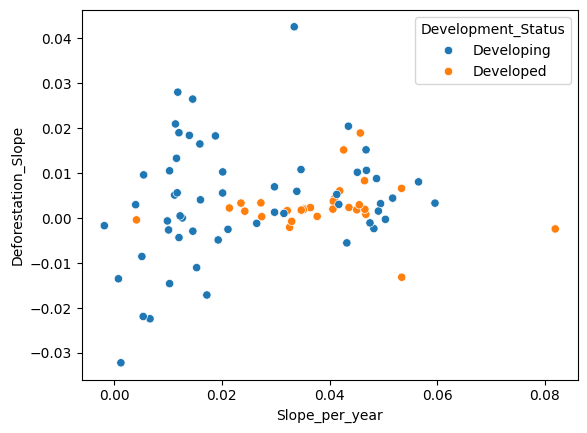

In [233]:
sns.scatterplot(
    data=merged_all,
    x="Slope_per_year",
    y="Deforestation_Slope",
    hue="Development_Status"
)

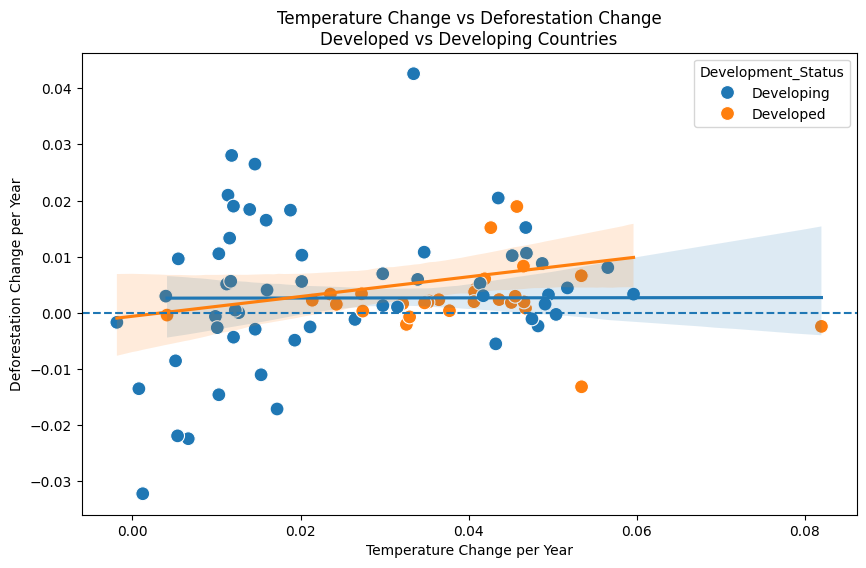

FULL DATASET
Slope: 0.10303245796199419
Intercept: 0.00034133883056601706
R-squared: 0.026663176407709994
P-value: 0.13538530043059793

DEVELOPED COUNTRIES
Slope: 0.0014184931905345884
Intercept: 0.002629547431877713
R-squared: 1.2309968063381993e-05
P-value: 0.9855885458604186

DEVELOPING COUNTRIES
Slope: 0.17574110984516933
Intercept: -0.0005899623589904934
R-squared: 0.054844609864875375
P-value: 0.08234589425642717


In [235]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_all,
    x="Slope_per_year",
    y="Deforestation_Slope",
    hue="Development_Status",
    s=100
)

# regression line for developed countries
sns.regplot(
    data=merged_all[
        merged_all["Development_Status"] == "Developed"
    ],
    x="Slope_per_year",
    y="Deforestation_Slope",
    scatter=False
)

# regression line for developing countries
sns.regplot(
    data=merged_all[
        merged_all["Development_Status"] == "Developing"
    ],
    x="Slope_per_year",
    y="Deforestation_Slope",
    scatter=False
)

plt.axhline(0, linestyle="--")

plt.xlabel("Temperature Change per Year")
plt.ylabel("Deforestation Change per Year")

plt.title(
    "Temperature Change vs Deforestation Change\n"
    "Developed vs Developing Countries"
)

plt.show()

# regression AFTER show
result = linregress(
    merged_all["Slope_per_year"],
    merged_all["Deforestation_Slope"]
)

print("FULL DATASET")
print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

developed_df = merged_all[
    merged_all["Development_Status"] == "Developed"
]


developed_result = linregress(
    developed_df["Slope_per_year"],
    developed_df["Deforestation_Slope"]
)

print("\nDEVELOPED COUNTRIES")
print("Slope:", developed_result.slope)
print("Intercept:", developed_result.intercept)
print("R-squared:", developed_result.rvalue**2)
print("P-value:", developed_result.pvalue)

developing_df = merged_all[
    merged_all["Development_Status"] == "Developing"
]


developing_result = linregress(
    developing_df["Slope_per_year"],
    developing_df["Deforestation_Slope"]
)

print("\nDEVELOPING COUNTRIES")
print("Slope:", developing_result.slope)
print("Intercept:", developing_result.intercept)
print("R-squared:", developing_result.rvalue**2)
print("P-value:", developing_result.pvalue)

<Axes: >

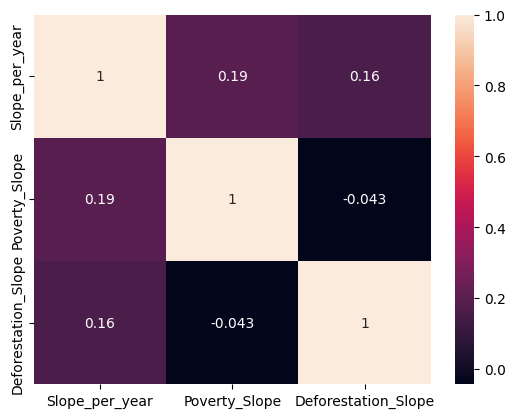

In [236]:
sns.heatmap(
    merged_all[
        [
            "Slope_per_year",
            "Poverty_Slope",
            "Deforestation_Slope"
        ]
    ].corr(),
    annot=True
)

In [171]:
merged_df.head()

,Country,Slope_per_year,Slope_per_decade,Poverty_Rate
0,Argentina,0.005127,0.051267,0.4
1,Armenia,0.045175,0.451748,1.4
2,Belarus,0.049492,0.494918,0.0
3,Bhutan,0.020509,0.205090,1.5
4,Bolivia,-0.001854,-0.018537,5.8


In [184]:
merged_df.shape

(23, 4)

In [173]:
merged_df.sort_values(
    by="Slope_per_year",
    ascending=False
).head(10)

,Country,Slope_per_year,Slope_per_decade,Poverty_Rate
17,Moldova,0.056550,0.565496,0.1
2,Belarus,0.049492,0.494918,0.0
13,Georgia,0.046791,0.467913,5.0
1,Armenia,0.045175,0.451748,1.4
9,Djibouti,0.034738,0.347384,17.1
16,Kazakhstan,0.033929,0.339290,0.0
3,Bhutan,0.020509,0.205090,1.5
21,Thailand,0.020154,0.201541,0.0
12,Gabon,0.020091,0.200908,3.4
5,Brazil,0.017202,0.172022,4.8


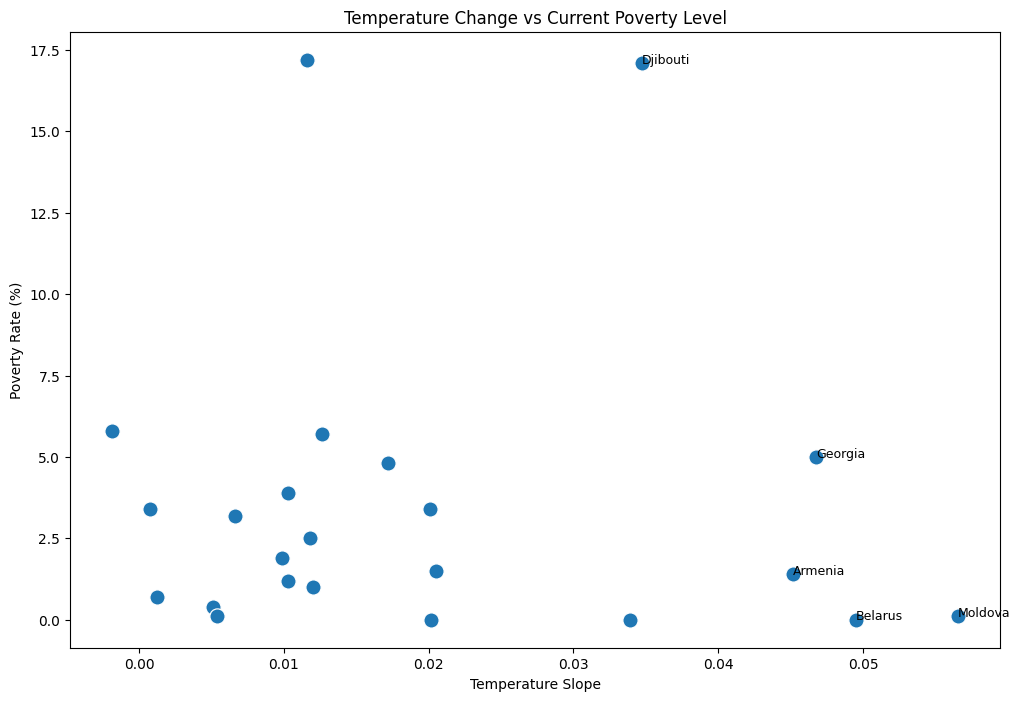

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=merged_df,
    x="Slope_per_year",
    y="Poverty_Rate",
    s=120
)

# Select countries to label
top_warming = merged_df.nlargest(5, "Slope_per_year")

# Add labels
for i, row in top_warming.iterrows():
    plt.text(
        row["Slope_per_year"],
        row["Poverty_Rate"],
        row["Country"],
        fontsize=9
    )

plt.title("Temperature Change vs Current Poverty Level")
plt.xlabel("Temperature Slope")
plt.ylabel("Poverty Rate (%)")

plt.show()

In [182]:
import plotly.express as px

fig = px.choropleth(
    merged_df,
    locations="Country",
    locationmode="country names",
    color="Slope_per_year",
    hover_name="Country",
    color_continuous_scale="RdYlBu_r",
    title="Temperature Change by Country"
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/435746400.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [183]:
import plotly.express as px

fig = px.choropleth(
    merged_df,
    locations="Country",
    locationmode="country names",
    color="Poverty_Rate",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Current Poverty Levels by Country"
)

fig.show()

/var/folders/10/rcqq4c4d7s9b5_358scx0wqh0000gn/T/ipykernel_21072/995681184.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [156]:
print(merged.isna().sum())

Country                                                                  0
Slope_per_year                                                           0
Slope_per_decade                                                         0
Country Name                                                           219
year                                                                   219
GINI index (World Bank estimate)                                       219
Number of poor at $1.90 a day (2011 PPP) (millions)                    219
Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)    219
dtype: int64


In [157]:
print(country_slope_df["Country"].head(20))
print(poverty_recent["Country Name"].head(20))

0             Afghanistan
1                  Africa
2                 Albania
3                 Algeria
4          American Samoa
5                 Andorra
6                  Angola
7                Anguilla
8     Antigua And Barbuda
9               Argentina
10                Armenia
11                  Aruba
12                   Asia
13              Australia
14                Austria
15             Azerbaijan
16                Bahamas
17                Bahrain
18           Baker Island
19             Bangladesh
Name: Country, dtype: str
38           Argentina
56             Armenia
114            Belarus
140             Bhutan
159            Bolivia
201             Brazil
256              Chile
288           Colombia
325         Costa Rica
386           Djibouti
428            Ecuador
460        El Salvador
513              Gabon
539            Georgia
623           Honduras
682          Indonesia
765         Kazakhstan
787             Kosovo
806    Kyrgyz Republic
947            Mo

In [161]:
country_slope_df["Country"] = (
    country_slope_df["Country"]
    .astype(str)
    .str.strip()
)

poverty_recent["Country Name"] = (
    poverty_recent["Country Name"]
    .astype(str)
    .str.strip()
)

In [162]:
set(country_slope_df["Country"]) - set(poverty_recent["Country Name"])

{'Afghanistan',
 'Africa',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua And Barbuda',
 'Aruba',
 'Asia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Baker Island',
 'Bangladesh',
 'Barbados',
 'Belgium',
 'Belize',
 'Benin',
 'Bonaire, Saint Eustatius And Saba',
 'Bosnia And Herzegovina',
 'Botswana',
 'British Virgin Islands',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'China',
 'Christmas Island',
 'Comoros',
 'Congo',
 'Congo (Democratic Republic Of The)',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech Republic',
 "Côte D'Ivoire",
 'Denmark',
 'Denmark (Europe)',
 'Dominica',
 'Dominican Republic',
 'Egypt',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Europe',
 'Falkland Islands (Islas Malvinas)',
 'Faroe Islands',
 'Federated States Of Micronesia',
 'Fiji',
 'Finland',
 'France

In [102]:
merged = yearly.merge(df_global, on="year", how="inner")

In [108]:
print(merged.head())
print(merged.columns)

   year  LandAverageTemperature  GINI index (World Bank estimate)  \
0  1977                8.850250                               NaN   
1  1979                8.733417                         39.866667   
2  1980                8.980333                         43.800000   
3  1981                9.165833                         44.800000   
4  1982                8.639167                         58.400000   

   Number of poor at $1.90 a day (2011 PPP) (millions)  \
0                                         410.200000     
1                                           0.433333     
2                                           2.050000     
3                                           5.385714     
4                                          27.600000     

   Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)  
0                                          61.600000                    
1                                           2.866667                    
2                

In [106]:
merged = merged.rename(columns={
    "AverageTemperature": "temperature"
})

In [109]:
merged.rename(columns={"LandAverageTemperature": "temperature"}, inplace=True)

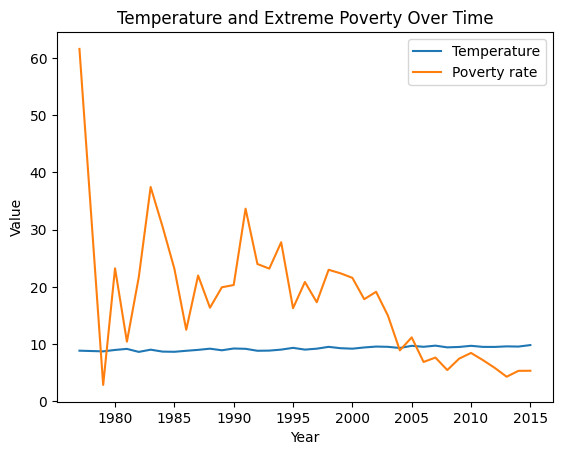

In [110]:
import matplotlib.pyplot as plt

poverty_col = "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population)"

plt.plot(merged["year"], merged["temperature"], label="Temperature")
plt.plot(merged["year"], merged[poverty_col], label="Poverty rate")

plt.title("Temperature and Extreme Poverty Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()